# 📰 News Intelligence System
### CA3 Project — NLP/LLM Use Case

This notebook implements a **News Intelligence System** that:
1. **Classifies** news articles into categories (World, Sports, Business, Tech)
2. **Summarizes** long articles into concise briefs
3. **Answers Questions** about the news using a QA pipeline
4. **Evaluates** the system using standard NLP metrics

---
**Dataset**: AG News (publicly available on Hugging Face)

**Models Used**:
- Classification: `distilbert-base-uncased` (fine-tuned on AG News)
- Summarization: `facebook/bart-large-cnn`
- Question Answering: `deepset/roberta-base-squad2`


## Step 1: Install Required Libraries

In [15]:
!pip install transformers==4.41.2 \
sentence-transformers==2.7.0 \
datasets==2.19.0 \
accelerate==0.30.1 \
faiss-cpu \
torch torchvision torchaudio \
evaluate==0.4.2 \
rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=5493ef6adacfc3d5ca69eb1a41225329bc0afde940628dc917af3bd7d19ef163
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


## Step 2: Import Libraries

In [4]:
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import faiss
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification
)
import evaluate
import warnings
warnings.filterwarnings('ignore')

# Confirm transformers version
import transformers
print(f"Transformers version: {transformers.__version__}")

# Check device
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU (CUDA)' if device == 0 else 'CPU'}")
print("All libraries imported successfully!")


Transformers version: 4.41.2
Device: GPU (CUDA)
All libraries imported successfully!


## Step 3: Load the AG News Dataset

AG News is a collection of news articles from 4 categories:
- **0 = World** news
- **1 = Sports** news
- **2 = Business** news
- **3 = Science/Technology** news

In [5]:
# Load AG News dataset
print("Loading AG News dataset...")
dataset = load_dataset("ag_news")

# Label mapping
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Science/Tech"}

# Preview dataset
print(f"\nDataset Info:")
print(f"  Training samples : {len(dataset['train'])}")
print(f"  Test samples     : {len(dataset['test'])}")
print(f"  Labels           : {label_map}")

# Show a few samples
print("\n--- Sample News Articles ---")
for i in range(3):
    sample = dataset['train'][i]
    print(f"\n[{i+1}] Category: {label_map[sample['label']]}")
    print(f"    Text: {sample['text'][:200]}...")

Loading AG News dataset...


Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


Dataset Info:
  Training samples : 120000
  Test samples     : 7600
  Labels           : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Science/Tech'}

--- Sample News Articles ---

[1] Category: Business
    Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

[2] Category: Business
    Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense in...

[3] Category: Business
    Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during t...


## Step 4: News Classification

We use a **pre-trained DistilBERT** model fine-tuned on AG News to classify articles into 4 categories.

**NLP Concept**: Text Classification using Transformer (Attention-based) model.

In [6]:
# Load pre-trained classifier (distilbert fine-tuned on AG News)
# Primary model: fabriceyhc/bert-base-uncased-ag_news
# Fallback model: textattack/bert-base-uncased-ag-news (if primary is unavailable)
print("Loading News Classifier model...")
try:
    classifier = pipeline(
        "text-classification",
        model="fabriceyhc/bert-base-uncased-ag_news",
        device=device
    )
    print("Classifier loaded! (primary model)")
except Exception as e:
    print(f"Primary model failed ({e}), trying fallback...")
    classifier = pipeline(
        "text-classification",
        model="textattack/bert-base-uncased-ag-news",
        device=device
    )
    print("Classifier loaded! (fallback model)")


Loading News Classifier model...


config.json:   0%|          | 0.00/919 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Classifier loaded! (primary model)


In [7]:
# Define our own label map to match the model's output labels
# The model returns labels like LABEL_0, LABEL_1, etc.
model_label_map = {
    "LABEL_0": "World",
    "LABEL_1": "Sports",
    "LABEL_2": "Business",
    "LABEL_3": "Science/Tech"
}

def classify_news(text):
    """Classify a news article into one of 4 categories."""
    result = classifier(text[:512])  # Limit to 512 tokens
    label = result[0]['label']
    score = result[0]['score']
    category = model_label_map.get(label, label)
    return category, score

# Test classification on sample articles
test_articles = [
    "NASA launches new Mars rover to explore the red planet's surface and search for signs of ancient life.",
    "The stock market surged today as Apple reported record quarterly earnings beating analyst expectations.",
    "Manchester United defeated Chelsea 3-1 in an exciting Premier League match at Old Trafford.",
    "World leaders gathered at the United Nations to discuss global climate change policies."
]

print("=" * 60)
print("        NEWS CLASSIFICATION RESULTS")
print("=" * 60)
for article in test_articles:
    category, confidence = classify_news(article)
    print(f"\nArticle : {article[:80]}...")
    print(f"Category: {category}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 60)

        NEWS CLASSIFICATION RESULTS

Article : NASA launches new Mars rover to explore the red planet's surface and search for ...
Category: Science/Tech
Confidence: 98.48%
------------------------------------------------------------

Article : The stock market surged today as Apple reported record quarterly earnings beatin...
Category: Business
Confidence: 98.30%
------------------------------------------------------------

Article : Manchester United defeated Chelsea 3-1 in an exciting Premier League match at Ol...
Category: World
Confidence: 83.95%
------------------------------------------------------------

Article : World leaders gathered at the United Nations to discuss global climate change po...
Category: World
Confidence: 99.15%
------------------------------------------------------------


## Step 5: News Summarization

We use **BART (Facebook)** — a sequence-to-sequence transformer — to generate concise summaries of news articles.

**NLP Concept**: Abstractive Summarization using Encoder-Decoder Transformer.

In [8]:
# Load summarization model (BART)
# FIX: 'summarization' is a valid task string in transformers==4.35.2
# If you see a KeyError here, ensure you ran Step 1 and restarted the runtime.
print("Loading Summarization model (BART)...")
try:
    summarizer = pipeline(
        "summarization",
        model="facebook/bart-large-cnn",
        device=device
    )
    print("Summarizer loaded!")
except Exception as e:
    print(f"Error loading summarizer: {e}")
    print("Tip: restart the runtime and re-run from Step 1 to apply the pinned version.")
    raise


Loading Summarization model (BART)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Summarizer loaded!


In [9]:
def summarize_news(text, max_length=80, min_length=30):
    """Generate a concise summary of a news article."""
    # Note: slicing by characters (~4 chars/token), so 1024 chars ~ 256 tokens.
    # BART's true limit is 1024 *tokens*; this is a safe conservative cut.
    result = summarizer(
        text[:1024],
        max_length=max_length,
        min_length=min_length,
        do_sample=False
    )
    return result[0]['summary_text']  # key for transformers==4.35.2

# Test with a long news article
long_article = """
Scientists at NASA's Jet Propulsion Laboratory announced on Monday that the Perseverance rover
has made a groundbreaking discovery on Mars. The rover, which landed in Jezero Crater in February 2021,
has collected rock samples that show potential biosignatures — chemical traces that could indicate
ancient microbial life. The discovery was made using Perseverance's SHERLOC instrument,
which uses Raman spectroscopy to analyze the chemical composition of rocks.
Researchers found organic molecules in three separate rock samples, which, combined with
the crater's history as an ancient lake bed, suggests conditions once favorable for life.
The samples have been sealed in titanium tubes and are awaiting a future Mars Sample Return mission,
expected to launch in the early 2030s, which will bring the samples to Earth for detailed analysis.
NASA administrator Bill Nelson called the discovery \"the most significant finding in the history
of Mars exploration\" and said it would reshape our understanding of the potential for life
beyond Earth. The European Space Agency (ESA), a partner in the Mars Sample Return mission,
echoed the excitement and pledged continued collaboration to bring the samples back to Earth safely.
"""

print("=" * 60)
print("          NEWS SUMMARIZATION")
print("=" * 60)
print(f"\nORIGINAL ARTICLE ({len(long_article.split())} words):")
print("-" * 60)
print(long_article.strip())

summary = summarize_news(long_article)
print(f"\nSUMMARY ({len(summary.split())} words):")
print("-" * 60)
print(summary)


          NEWS SUMMARIZATION

ORIGINAL ARTICLE (185 words):
------------------------------------------------------------
Scientists at NASA's Jet Propulsion Laboratory announced on Monday that the Perseverance rover 
has made a groundbreaking discovery on Mars. The rover, which landed in Jezero Crater in February 2021, 
has collected rock samples that show potential biosignatures — chemical traces that could indicate 
ancient microbial life. The discovery was made using Perseverance's SHERLOC instrument, 
which uses Raman spectroscopy to analyze the chemical composition of rocks. 
Researchers found organic molecules in three separate rock samples, which, combined with 
the crater's history as an ancient lake bed, suggests conditions once favorable for life.
The samples have been sealed in titanium tubes and are awaiting a future Mars Sample Return mission, 
expected to launch in the early 2030s, which will bring the samples to Earth for detailed analysis.
NASA administrator Bill Nelson

## Step 6: Question Answering on News Articles

We use **RoBERTa fine-tuned on SQuAD2** to answer specific questions about a news article.

**NLP Concept**: Extractive QA — the model finds the answer span directly from the context (article).

In [10]:
# Load QA model
print("Loading Question Answering model (RoBERTa)...")
qa_model = pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2",
    device=device
)
print("QA model loaded!")

Loading Question Answering model (RoBERTa)...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

QA model loaded!


In [11]:
def answer_question(question, context):
    """Answer a question based on the provided news context."""
    result = qa_model(question=question, context=context)
    return result['answer'], result['score']

# Test QA on our article
questions = [
    "Where did Perseverance rover land?",
    "What instrument was used to analyze rocks?",
    "When is the Mars Sample Return mission expected to launch?",
    "Who is the NASA administrator?"
]

print("=" * 60)
print("      QUESTION ANSWERING ON NEWS ARTICLE")
print("=" * 60)
print(f"\nContext: {long_article[:300].strip()}...\n")
print("-" * 60)

for q in questions:
    answer, confidence = answer_question(q, long_article)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print(f"   Confidence: {confidence:.2%}")
    print()

      QUESTION ANSWERING ON NEWS ARTICLE

Context: Scientists at NASA's Jet Propulsion Laboratory announced on Monday that the Perseverance rover 
has made a groundbreaking discovery on Mars. The rover, which landed in Jezero Crater in February 2021, 
has collected rock samples that show potential biosignatures — chemical traces that could indicate...

------------------------------------------------------------
Q: Where did Perseverance rover land?
A: Jezero Crater
   Confidence: 96.20%

Q: What instrument was used to analyze rocks?
A: SHERLOC
   Confidence: 49.10%

Q: When is the Mars Sample Return mission expected to launch?
A: early 2030s
   Confidence: 39.76%

Q: Who is the NASA administrator?
A: Bill Nelson
   Confidence: 97.26%



## Step 7: Full Pipeline — Classify + Summarize + QA

In [12]:
def news_intelligence_pipeline(article, questions=None):
    """
    Full News Intelligence Pipeline:
    1. Classify the article
    2. Summarize it
    3. Answer any questions about it
    """
    print("=" * 65)
    print("         NEWS INTELLIGENCE SYSTEM — FULL PIPELINE")
    print("=" * 65)

    # Step 1: Classify
    category, conf = classify_news(article)
    print(f"\n[1] CLASSIFICATION")
    print(f"    Category   : {category}")
    print(f"    Confidence : {conf:.2%}")

    # Step 2: Summarize
    summary = summarize_news(article)
    print(f"\n[2] SUMMARY")
    print(f"    {summary}")

    # Step 3: Answer questions
    if questions:
        print(f"\n[3] QUESTION ANSWERING")
        for q in questions:
            ans, score = answer_question(q, article)
            print(f"    Q: {q}")
            print(f"    A: {ans}  (confidence: {score:.2%})")
            print()

    print("=" * 65)

# Demo article
demo_article = """
Apple Inc. reported its fiscal fourth-quarter earnings on Thursday, surpassing Wall Street
expectations with revenue of $94.9 billion and earnings per share of $1.46. iPhone sales
led the growth with a 12% year-over-year increase, driven by strong demand for the iPhone 16 series
in emerging markets. CEO Tim Cook highlighted the expansion into India and Southeast Asia as key
drivers of growth. The company also announced a $110 billion share buyback program — the largest
in the company's history — signaling strong confidence in its future prospects. Apple's services
division, which includes the App Store, Apple Music, and iCloud, grew 14% to reach $24.2 billion,
reinforcing the company's transition toward recurring revenue streams.
"""

demo_questions = [
    "What was Apple's revenue?",
    "Who is Apple's CEO?",
    "What was the size of the share buyback?"
]

news_intelligence_pipeline(demo_article, demo_questions)

         NEWS INTELLIGENCE SYSTEM — FULL PIPELINE

[1] CLASSIFICATION
    Category   : Science/Tech
    Confidence : 96.16%

[2] SUMMARY
    Apple reported revenue of $94.9 billion and earnings per share of $1.46. iPhone sales increased 12% year-over-year. CEO Tim Cook highlighted the expansion into India and Southeast Asia as key drivers of growth.

[3] QUESTION ANSWERING
    Q: What was Apple's revenue?
    A: $94.9 billion  (confidence: 93.09%)

    Q: Who is Apple's CEO?
    A: Tim Cook  (confidence: 97.68%)

    Q: What was the size of the share buyback?
    A: $110 billion  (confidence: 89.50%)



## Step 8: Evaluation Metrics

We evaluate the system using:
- **Accuracy** — for classification
- **ROUGE Score** — for summarization quality
- **F1 / Exact Match** — for QA evaluation

In [27]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# ---- 8A: Evaluate Classification Accuracy ----
print("Evaluating Classification Accuracy on test samples...")

# Use a small subset of test data for quick evaluation
test_subset = dataset['test'].select(range(100))

correct = 0
total = len(test_subset)

true_labels_list = []
pred_labels_list = []

for sample in test_subset:
    text = sample['text']
    true_label = label_map[sample['label']]
    pred_label, _ = classify_news(text)

    true_labels_list.append(true_label)
    pred_labels_list.append(pred_label)

    if pred_label == true_label:
        correct += 1

accuracy = correct / total
print(f"\nClassification Results (on {total} test samples):")
print(f"  Correct Predictions : {correct}")
print(f"  Total Samples       : {total}")
print(f"  Accuracy            : {accuracy:.2%}")


Evaluating Classification Accuracy on test samples...

Classification Results (on 100 test samples):
  Correct Predictions : 96
  Total Samples       : 100
  Accuracy            : 96.00%


Generating Confusion Matrix...


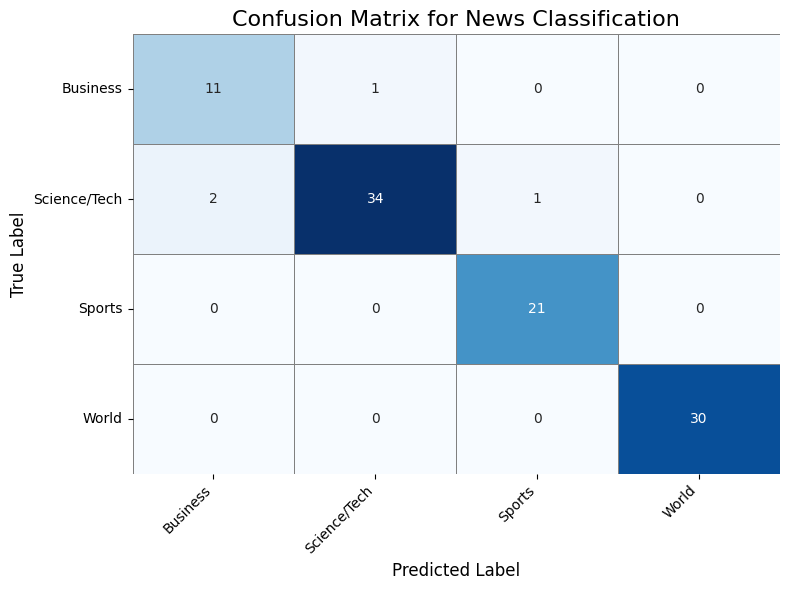

In [28]:
# ---- 8D: Visualize Confusion Matrix for Classification ----
print("Generating Confusion Matrix...")

# Get all unique labels to ensure consistent order in the matrix
labels = sorted(list(set(true_labels_list + pred_labels_list)))

cm = confusion_matrix(true_labels_list, pred_labels_list, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True, linewidths=.5, linecolor='gray')
plt.title('Confusion Matrix for News Classification', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# ---- 8B: Evaluate Summarization using ROUGE ----
print("Evaluating Summarization with ROUGE Score...")

rouge = evaluate.load("rouge")

# Sample articles with reference summaries
sample_pairs = [
    {
        "article": """Scientists have discovered a new species of deep-sea fish in the Pacific Ocean
        at a depth of over 8,000 meters. The fish, named Pseudoliparis belyaevi, was found in the
        Mariana Trench during a research expedition led by the University of Western Australia.
        The discovery marks the deepest fish ever recorded, surpassing the previous record set in 2008.
        Researchers captured footage of the snailfish using deep-sea landers equipped with cameras and traps.""",
        "reference": "A new deep-sea fish species was discovered in the Mariana Trench at over 8,000 meters depth."
    },
    {
        "article": """The Federal Reserve raised interest rates by 25 basis points on Wednesday,
        bringing the benchmark rate to its highest level in 22 years. Fed Chair Jerome Powell
        signaled that further hikes may be needed to bring inflation back to the 2% target.
        The move was widely expected by markets, and stocks showed a muted reaction following the announcement.
        Mortgage rates are expected to remain elevated throughout the year as a result of the decision.""",
        "reference": "The Federal Reserve raised rates by 25 basis points to a 22-year high, with potential for further increases."
    }
]

generated_summaries = []
reference_summaries = []

for pair in sample_pairs:
    gen_summary = summarize_news(pair["article"])
    generated_summaries.append(gen_summary)
    reference_summaries.append(pair["reference"])
    print(f"\nGenerated : {gen_summary}")
    print(f"Reference : {pair['reference']}")

# Compute ROUGE
results = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("\n--- ROUGE Scores ---")
print(f"  ROUGE-1 (unigram overlap) : {results['rouge1']:.4f}")
print(f"  ROUGE-2 (bigram overlap)  : {results['rouge2']:.4f}")
print(f"  ROUGE-L (LCS-based)       : {results['rougeL']:.4f}")

Evaluating Summarization with ROUGE Score...

Generated : Pseudoliparis belyaevi was found in the Mariana Trench. Discovery marks the deepest fish ever recorded.
Reference : A new deep-sea fish species was discovered in the Mariana Trench at over 8,000 meters depth.

Generated : The Federal Reserve raised interest rates by 25 basis points on Wednesday. The move was widely expected by markets. Mortgage rates are expected to remain elevated throughout the year.
Reference : The Federal Reserve raised rates by 25 basis points to a 22-year high, with potential for further increases.

--- ROUGE Scores ---
  ROUGE-1 (unigram overlap) : 0.4110
  ROUGE-2 (bigram overlap)  : 0.2489
  ROUGE-L (LCS-based)       : 0.3807


In [17]:
# ---- 8C: Evaluate QA using Exact Match and F1 ----
print("Evaluating Question Answering (Exact Match & F1)...")

def normalize_text(text):
    """Lowercase and strip whitespace."""
    return text.lower().strip()

def compute_f1(prediction, ground_truth):
    """Compute token-level F1 score."""
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()
    common = set(pred_tokens) & set(gt_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gt_tokens)
    f1 = 2 * precision * recall / (precision + recall)
    return f1

def compute_exact_match(prediction, ground_truth):
    """Check if prediction exactly matches ground truth."""
    return int(normalize_text(prediction) == normalize_text(ground_truth))

# QA test set with known answers
qa_test_set = [
    {
        "context": "Elon Musk founded SpaceX in 2002. The company is headquartered in Hawthorne, California.",
        "question": "When was SpaceX founded?",
        "ground_truth": "2002"
    },
    {
        "context": "The Eiffel Tower is located in Paris, France. It was built in 1889 for the World's Fair.",
        "question": "Where is the Eiffel Tower located?",
        "ground_truth": "Paris, France"
    },
    {
        "context": "Amazon was founded by Jeff Bezos in 1994 in Bellevue, Washington.",
        "question": "Who founded Amazon?",
        "ground_truth": "Jeff Bezos"
    }
]

em_scores = []
f1_scores = []

print("\n--- QA Evaluation Results ---")
for qa in qa_test_set:
    predicted, conf = answer_question(qa["question"], qa["context"])
    em = compute_exact_match(predicted, qa["ground_truth"])
    f1 = compute_f1(predicted, qa["ground_truth"])
    em_scores.append(em)
    f1_scores.append(f1)

    print(f"\nQuestion   : {qa['question']}")
    print(f"Predicted  : {predicted}")
    print(f"Expected   : {qa['ground_truth']}")
    print(f"EM         : {em} | F1: {f1:.2f} | Confidence: {conf:.2%}")

print("\n=" * 50)
print(f"Average Exact Match : {np.mean(em_scores):.2%}")
print(f"Average F1 Score    : {np.mean(f1_scores):.2f}")

Evaluating Question Answering (Exact Match & F1)...

--- QA Evaluation Results ---

Question   : When was SpaceX founded?
Predicted  : 2002
Expected   : 2002
EM         : 1 | F1: 1.00 | Confidence: 97.23%

Question   : Where is the Eiffel Tower located?
Predicted  : Paris, France
Expected   : Paris, France
EM         : 1 | F1: 1.00 | Confidence: 93.89%

Question   : Who founded Amazon?
Predicted  : Jeff Bezos
Expected   : Jeff Bezos
EM         : 1 | F1: 1.00 | Confidence: 98.15%

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Average Exact Match : 100.00%
Average F1 Score    : 1.00


## Step 9: Results Summary

In [18]:
print("="*65)
print("         NEWS INTELLIGENCE SYSTEM — EVALUATION SUMMARY")
print("="*65)
print()
print("TASK 1: NEWS CLASSIFICATION")
print(f"   Model   : BERT fine-tuned on AG News")
print(f"   Accuracy: {accuracy:.2%} (on 100 test samples)")
print()
print("TASK 2: NEWS SUMMARIZATION")
print(f"   Model   : facebook/bart-large-cnn")
print(f"   ROUGE-1 : {results['rouge1']:.4f}")
print(f"   ROUGE-2 : {results['rouge2']:.4f}")
print(f"   ROUGE-L : {results['rougeL']:.4f}")
print()
print("TASK 3: QUESTION ANSWERING")
print(f"   Model   : deepset/roberta-base-squad2")
print(f"   Avg EM  : {np.mean(em_scores):.2%}")
print(f"   Avg F1  : {np.mean(f1_scores):.2f}")
print()
print("="*65)
print("   NLP Concepts Applied:")
print("   - Transformer (BERT, RoBERTa, BART) with Attention")
print("   - Text Classification")
print("   - Abstractive Summarization (Seq2Seq)")
print("   - Extractive Question Answering (Span Extraction)")
print("   - Evaluation: Accuracy, ROUGE, F1, Exact Match")
print("="*65)

         NEWS INTELLIGENCE SYSTEM — EVALUATION SUMMARY

TASK 1: NEWS CLASSIFICATION
   Model   : BERT fine-tuned on AG News
   Accuracy: 96.00% (on 100 test samples)

TASK 2: NEWS SUMMARIZATION
   Model   : facebook/bart-large-cnn
   ROUGE-1 : 0.4110
   ROUGE-2 : 0.2489
   ROUGE-L : 0.3807

TASK 3: QUESTION ANSWERING
   Model   : deepset/roberta-base-squad2
   Avg EM  : 100.00%
   Avg F1  : 1.00

   NLP Concepts Applied:
   - Transformer (BERT, RoBERTa, BART) with Attention
   - Text Classification
   - Abstractive Summarization (Seq2Seq)
   - Extractive Question Answering (Span Extraction)
   - Evaluation: Accuracy, ROUGE, F1, Exact Match


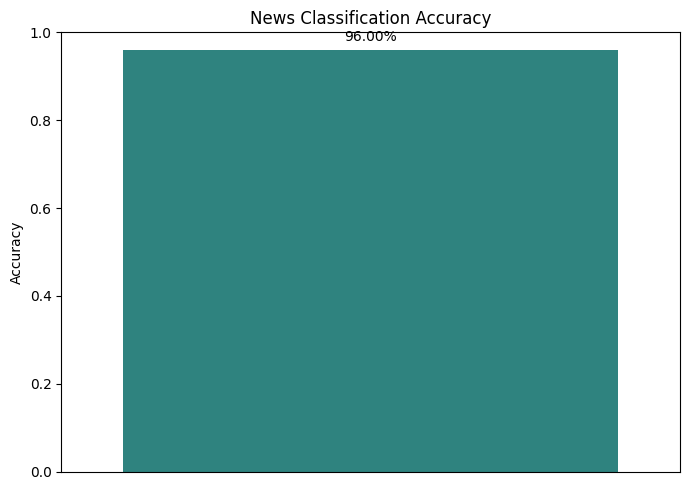

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization for Classification Accuracy
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=['Classification Accuracy'], y=[accuracy], ax=ax, palette='viridis')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('News Classification Accuracy')
ax.set_xticks([]) # Remove x-axis ticks
ax.set_xlabel('')  # Remove x-axis label
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.tight_layout()
plt.show()

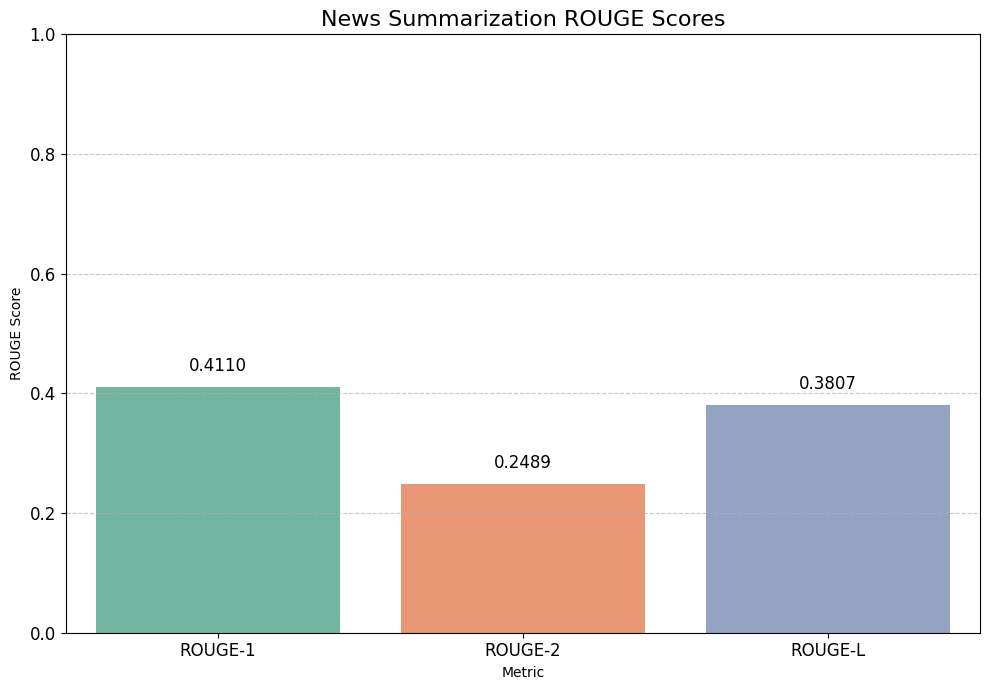

In [26]:
# Visualization for Summarization ROUGE Scores
rouge_scores_data = {
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'Score': [results['rouge1'], results['rouge2'], results['rougeL']]
}
rouge_df = pd.DataFrame(rouge_scores_data)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x='Metric', y='Score', data=rouge_df, palette=['#66c2a5', '#fc8d62', '#8da0cb'], ax=ax) # Using a distinct color palette
ax.set_ylim(0, 1)
ax.set_ylabel('ROUGE Score')
ax.set_title('News Summarization ROUGE Scores', fontsize=16)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add gridlines
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=12)
plt.tight_layout()
plt.show()

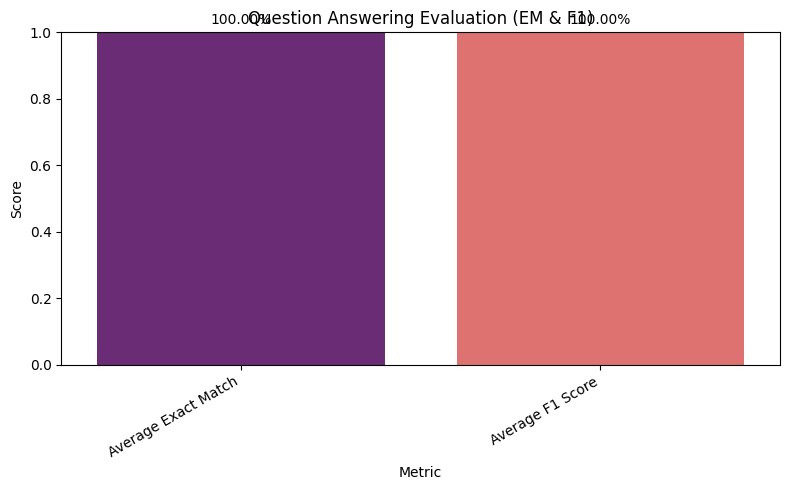

In [25]:
# Visualization for Question Answering EM and F1 Scores
qa_scores_data = {
    'Metric': ['Average Exact Match', 'Average F1 Score'],
    'Score': [np.mean(em_scores), np.mean(f1_scores)]
}
qa_df = pd.DataFrame(qa_scores_data)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=qa_df, palette='magma', ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Question Answering Evaluation (EM & F1)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.xticks(rotation=30, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()